# NYC Airbnb Analysis (AB_NYC_2019)

## 1. Objective and Questions

This notebook is designed to help rebuild practical Python data analysis skills using a real dataset.

**Goal:** Understand pricing and supply patterns in NYC Airbnb listings, then build a simple model to predict price.

### Questions we will answer
1. Which neighbourhood groups (boroughs) have the most listings?
2. Which room types are most common?
3. How does price vary by neighbourhood group and room type?
4. Which variables correlate with price?
5. How do minimum_nights and availability_365 relate to price?
6. Are there strong outliers in price, and how do they affect conclusions?
7. Do professional hosts (many listings) price differently?
8. How does number_of_reviews relate to price?
9. How recent are reviews, and does recency relate to price?
10. Can a simple model predict log(price) reasonably well?


## 2. Imports and Setup

We use only a small set of common libraries:
- pandas and numpy for data work
- matplotlib for plots
- scikit-learn for simple modeling


In [101]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make plots a bit larger and readable
plt.rcParams["figure.figsize"] = (10, 6)

# Reproducibility
RANDOM_STATE = 42

# Dataset source (public mirror)
DATA_URL = "https://raw.githubusercontent.com/selva86/datasets/master/AB_NYC_2019.csv"
# Output folder
project_dir = Path.cwd()
outputs_dir = project_dir / "outputs"
outputs_dir.mkdir(exist_ok=True)
outputs_dir


WindowsPath('C:/Users/rajat/Downloads/outputs')

## 3. Load the Dataset

We download the dataset directly from a public URL and load it with pandas.


In [102]:
#df_raw = pd.read_csv(DATA_URL)
df_raw = pd.read_csv(r"C:\Users\Rajat\Downloads\AB_NYC_2019.csv")
df_raw.shape


(48895, 16)

In [103]:
df_raw.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Overview
The dataset contains NYC Airbnb listings with information about pricing, location, host behavior, and listing characteristics. Each row represents a listing.

Important fields used in this analysis include:
- `neighbourhood_group`
- `room_type`
- `price`
- `reviews_per_month`
- `availability_365`
- `minimum_nights`
- `host_listing_count`

## 4. Initial Exploration

We quickly inspect:
- columns and data types
- basic missing values
- a few summary stats


In [104]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [105]:
df_raw.describe(include="all").T.head(25)     #transposing and "all" for inlcuding non-numeric collumns also

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [106]:
missing_counts = df_raw.isna().sum().sort_values(ascending=False) # missing_counts is a pandas series object
missing_pct = (missing_counts / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_summary.head(20)

,missing_count,missing_pct
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03
id,0,0.00
host_id,0,0.00
neighbourhood_group,0,0.00
neighbourhood,0,0.00
latitude,0,0.00
longitude,0,0.00


## 5. Data Cleaning (explicit and step-by-step)

We will:
1. Standardize column names (snake_case)
2. Remove exact duplicates
3. Convert dates
4. Handle missing values with clear rules

Important: We keep the original data in `df_raw` and make a new cleaned dataframe.


In [107]:
df = df_raw.copy()

# 1) Standardize column names to snake_case
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

df.columns.tolist()


['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [108]:
# 2columnsemove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Rows before: {before:,}")
print(f"Rows after : {after:,}")
print(f"Removed   : {before - after:,}")


Rows before: 48,895
Rows after : 48,895
Removed   : 0


In [109]:
# 3) Convert last_review to datetime (it has missing values)
if "last_review" in df.columns:
    df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

df[["last_review"]].head()


,last_review
0,2018-10-19
1,2019-05-21
2,NaT
3,2019-07-05
4,2018-11-19


### Missing values rules

Common missing patterns in this dataset:
- `name` and `host_name` can be missing. We can fill them with a placeholder because they are identifiers, not numeric signals.
- `reviews_per_month` is missing when a listing has no reviews. Filling with 0 is reasonable.
- For modeling, we will handle remaining missing values using `SimpleImputer` inside the model pipeline.


In [110]:
# Fill simple text fields with placeholder
for col in ["name", "host_name"]:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")

# reviews_per_month: missing usually means no reviews, so fill with 0
if "reviews_per_month" in df.columns:
    # 1 = has at least one review (not missing)
    # 0 = was never reviewed (was missing)
    df["has_reviews"] = df["reviews_per_month"].notna().astype(int)
    df["reviews_per_month_filled"] = df["reviews_per_month"].fillna(0.0)
else:
    df["reviews_per_month_filled"] = 0.0  # so this columns will always exist

df[["reviews_per_month", "reviews_per_month_filled", "has_reviews"]].head(10)  #comparing old with new


,reviews_per_month,reviews_per_month_filled,has_reviews
0,0.21,0.21,1
1,0.38,0.38,1
2,NaN,0.00,0
3,4.64,4.64,1
4,0.10,0.10,1
5,0.59,0.59,1
6,0.40,0.40,1
7,3.47,3.47,1
8,0.99,0.99,1
9,1.33,1.33,1


## 6. Feature Engineering (clear and manual)

We create a few practical features:
- `price_log1p`: log1p(price) for more stable modeling
- `price_capped`: cap price at the 99th percentile to reduce extreme outlier influence
- `host_listing_count`: number of listings per host_id (computed from the dataset)
- `is_professional_host`: host_listing_count >= 5
- `days_since_last_review`: based on the most recent review date in the dataset


In [111]:
# Ensure price is numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Remove non-positive prices (rare but possible) also zeroes
df = df[df["price"].notna() & (df["price"] > 0)].copy()

# log transform (log(1 + x)) safer
df["price_log1p"] = np.log1p(df["price"])

# cap price at 99th percentile
price_cap = df["price"].quantile(0.99)
df["price_capped"] = df["price"].clip(upper=price_cap)   # This reduces extreme outlier influence without deleting rows.

price_cap


799.0

In [112]:
# host listing count from host_id frequency
df["host_listing_count"] = df.groupby("host_id")["id"].transform("count")

# professional host flag
df["is_professional_host"] = df["host_listing_count"] >= 5

df[["host_id", "host_listing_count", "is_professional_host"]].head(10)


,host_id,host_listing_count,is_professional_host
0,2787,6,True
1,2845,2,False
2,4632,1,False
3,4869,1,False
4,7192,1,False
5,7322,1,False
6,7356,1,False
7,8967,1,False
8,7490,1,False
9,7549,4,False


In [113]:
# days since last review
if "last_review" in df.columns:
    max_review_date = df["last_review"].max()
    df["days_since_last_review"] = (max_review_date - df["last_review"]).dt.days
    # For missing last_review, days_since_last_review becomes NaN. Keep it as NaN for now.
else:
    df["days_since_last_review"] = np.nan

max_review_date
df[["days_since_last_review"]]

,days_since_last_review
0,262.0
1,48.0
2,NaN
3,3.0
4,231.0
...,...
48890,NaN
48891,NaN
48892,NaN
48893,NaN


Save a small cleaned sample for GitHub friendliness.


In [114]:
cleaned_sample_path = outputs_dir / "cleaned_sample.csv"
df.head(200).to_csv(cleaned_sample_path, index=False)
cleaned_sample_path

WindowsPath('C:/Users/rajat/Downloads/outputs/cleaned_sample.csv')

## 7. Exploratory Data Analysis (matplotlib only)

We will:
- Look at supply (counts) by borough and room type
- Study price distributions (raw and capped)
- Compare price across boroughs and room types (using capped price)
- Check a few relationships with scatter plots


In [115]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64

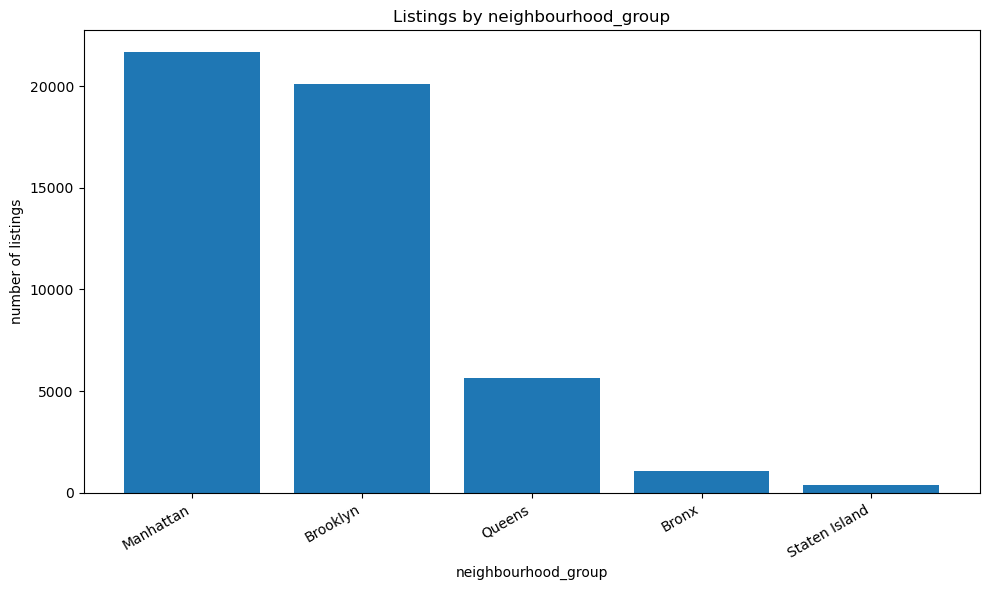

In [116]:
# Plot 1: Listings by neighbourhood_group
counts_ng = df["neighbourhood_group"].value_counts().sort_values(ascending=False)

plt.figure()
plt.bar(counts_ng.index, counts_ng.values)
plt.title("Listings by neighbourhood_group")
plt.xlabel("neighbourhood_group")
plt.ylabel("number of listings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


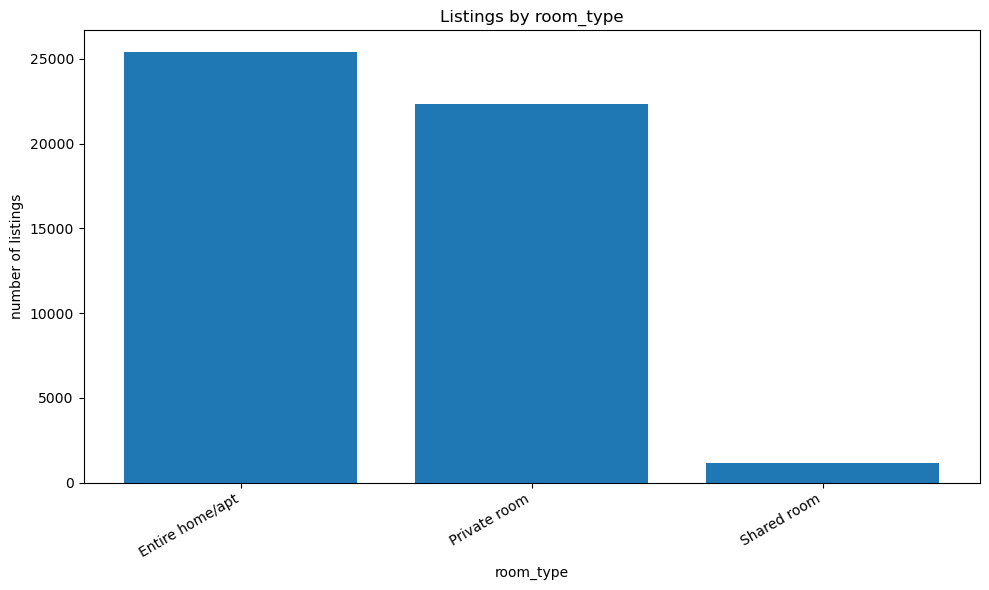

In [117]:
# Plot 2: Listings by room_type
counts_rt = df["room_type"].value_counts().sort_values(ascending=False)

plt.figure()
plt.bar(counts_rt.index, counts_rt.values)
plt.title("Listings by room_type")
plt.xlabel("room_type")
plt.ylabel("number of listings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


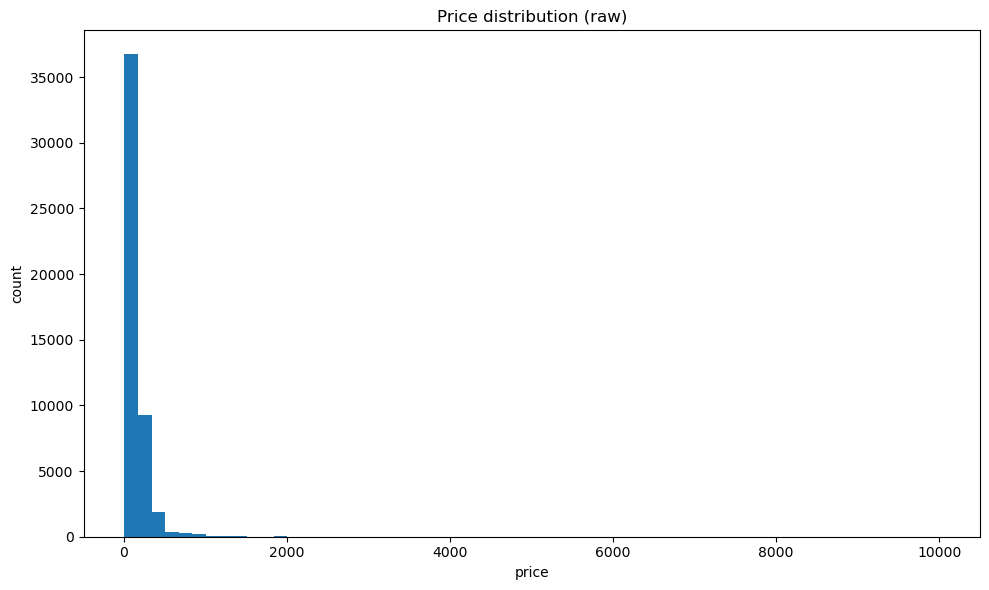

In [118]:
# Plot 3: Price distribution (raw)
plt.figure()
plt.hist(df["price"], bins=60)
plt.title("Price distribution (raw)")
plt.xlabel("price")
plt.ylabel("count")
plt.tight_layout()
plt.show()


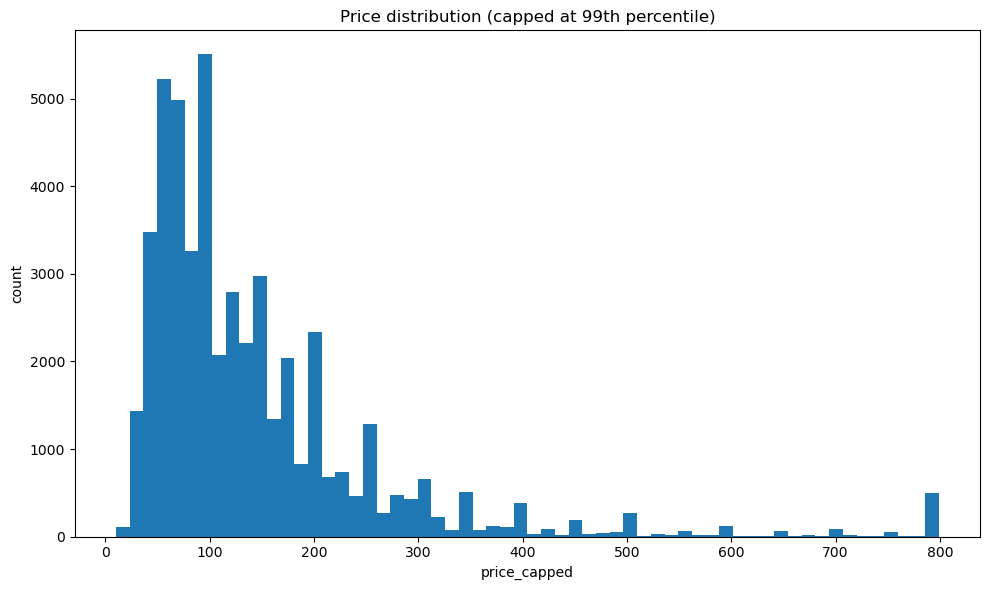

In [119]:
# Plot 4: Price distribution (capped at 99th percentile)
plt.figure()
plt.hist(df["price_capped"], bins=60)
plt.title("Price distribution (capped at 99th percentile)")
plt.xlabel("price_capped")
plt.ylabel("count")
plt.tight_layout()
plt.show()


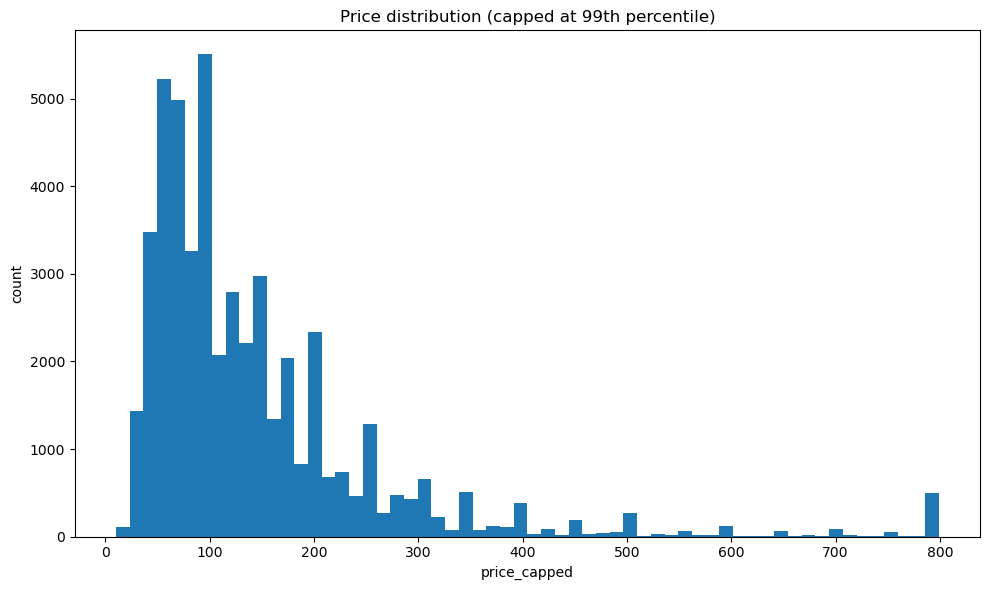

WindowsPath('C:/Users/rajat/Downloads/outputs/price_distribution.png')

In [120]:
# Same code but saving this key figure for GitHub deliverables
fig_path = outputs_dir / "price_distribution.png"
plt.figure()
plt.hist(df["price_capped"], bins=60)
plt.title("Price distribution (capped at 99th percentile)")
plt.xlabel("price_capped")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(fig_path, dpi=150)  # for saving
plt.show()

fig_path


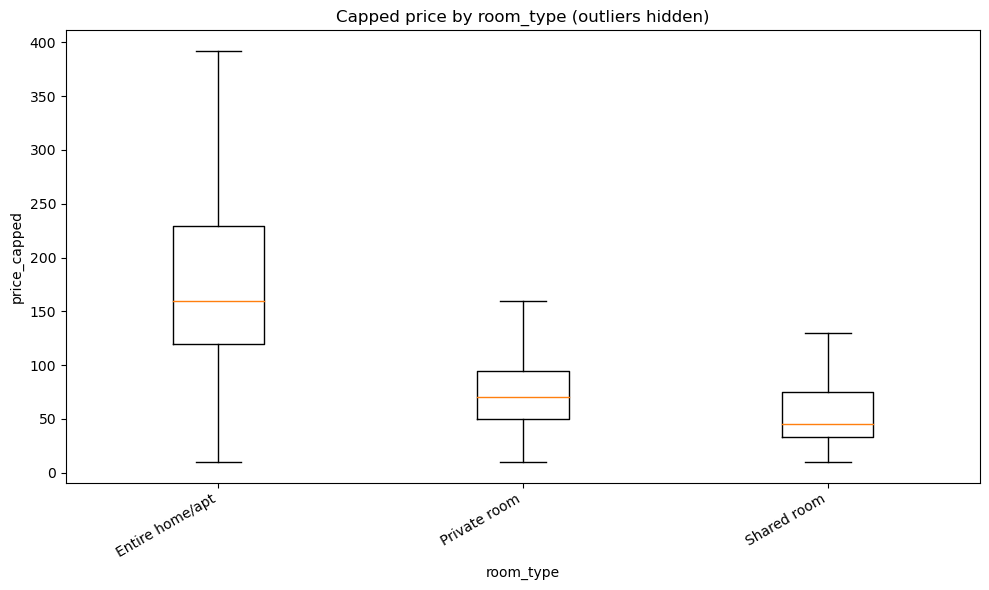

In [121]:
# Plot 5: Boxplot of capped price by room_type
room_types = sorted(df["room_type"].dropna().unique().tolist())
data_by_room = [df.loc[df["room_type"] == rt, "price_capped"].values for rt in room_types]  # Boxplot needs data grouped like this.

plt.figure()
plt.boxplot(data_by_room, labels=room_types, showfliers=False)
plt.title("Capped price by room_type (outliers hidden)")
plt.xlabel("room_type")
plt.ylabel("price_capped")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


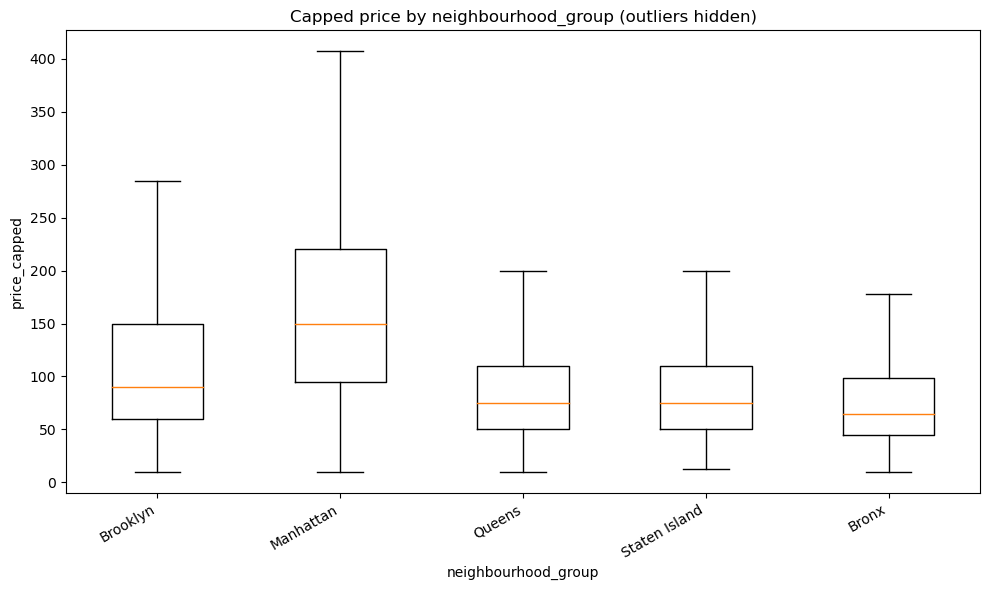

In [122]:
# Plot 6: Boxplot of capped price by neighbourhood_group
ngs = df["neighbourhood_group"].dropna().unique().tolist()
data_by_ng = [df.loc[df["neighbourhood_group"] == ng, "price_capped"].values for ng in ngs]

plt.figure()
plt.boxplot(data_by_ng, labels=ngs, showfliers=False)
plt.title("Capped price by neighbourhood_group (outliers hidden)")
plt.xlabel("neighbourhood_group")
plt.ylabel("price_capped")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


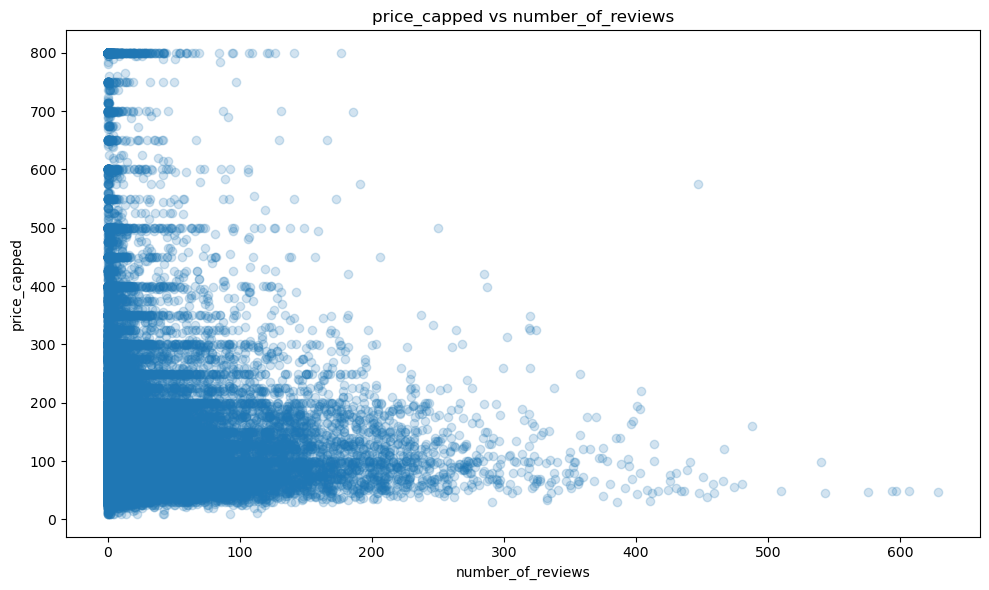

In [123]:
# Plot 7: Scatter price_capped vs number_of_reviews
plt.figure()
plt.scatter(df["number_of_reviews"], df["price_capped"], alpha=0.2)
plt.title("price_capped vs number_of_reviews")
plt.xlabel("number_of_reviews")
plt.ylabel("price_capped")
plt.tight_layout()
plt.show()


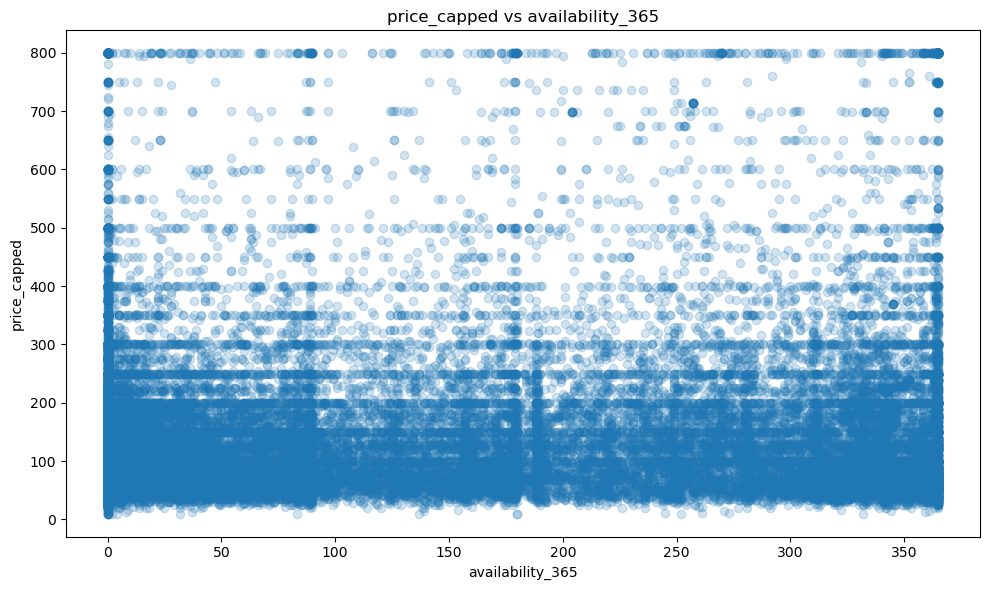

In [124]:
# Plot 8: Scatter price_capped vs availability_365
plt.figure()
plt.scatter(df["availability_365"], df["price_capped"], alpha=0.2)
plt.title("price_capped vs availability_365")
plt.xlabel("availability_365")
plt.ylabel("price_capped")
plt.tight_layout()
plt.show()


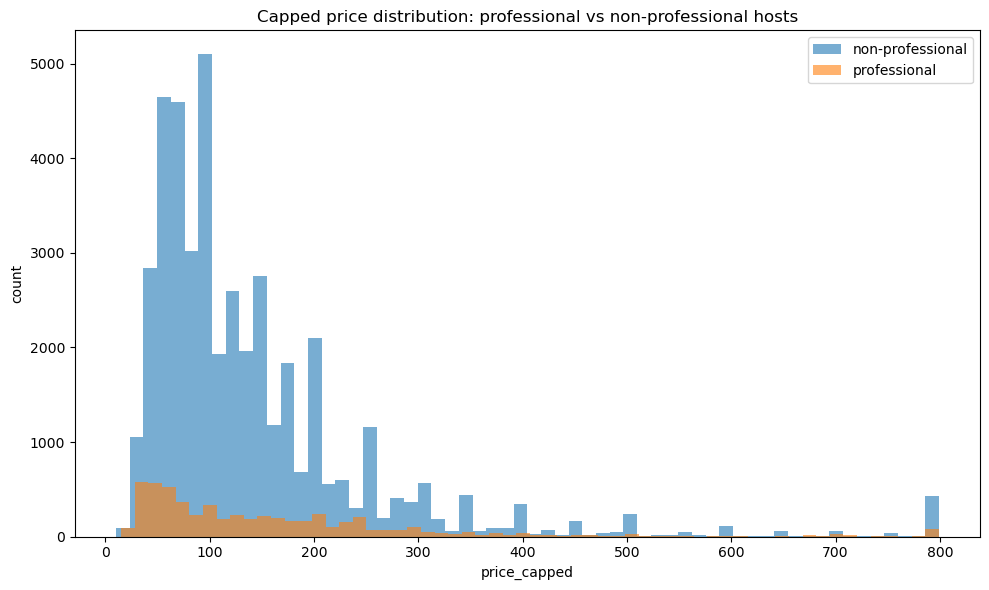

In [127]:
# Plot 9: Professional vs non-professional host price comparison (capped)
pro = df.loc[df["is_professional_host"], "price_capped"]    # When you pass a boolean Series as the row selector (1st argument), pandas keeps only the True rows.
nonpro = df.loc[~df["is_professional_host"], "price_capped"]

plt.figure()
plt.hist(nonpro, bins=60, alpha=0.6, label="non-professional")
plt.hist(pro, bins=60, alpha=0.6, label="professional")
plt.title("Capped price distribution: professional vs non-professional hosts")
plt.xlabel("price_capped")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()


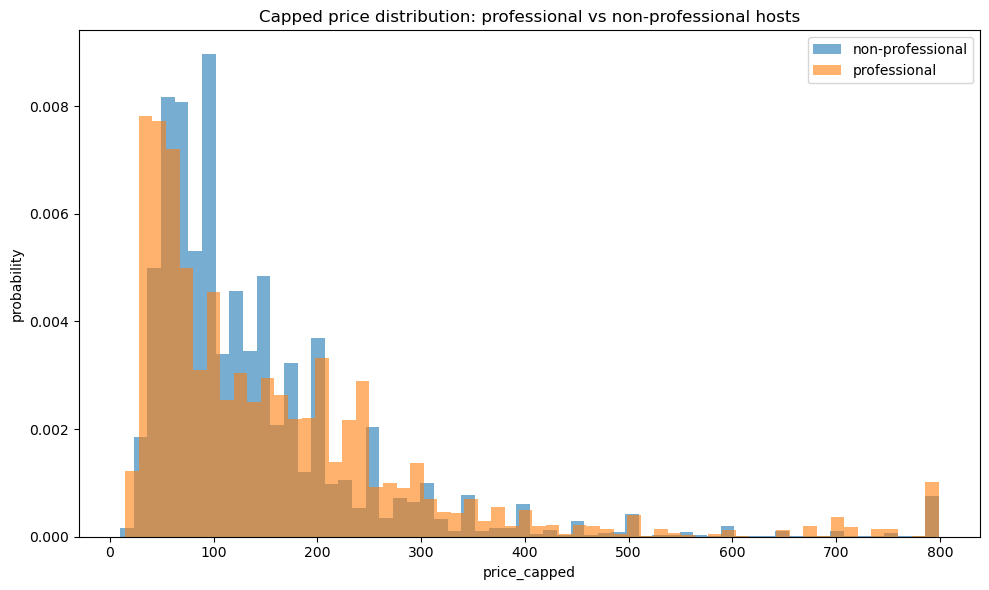

In [129]:
# To compare price behaviour between groups, you should normalize the histograms.
pro = df.loc[df["is_professional_host"], "price_capped"]    # When you pass a boolean Series as the row selector (1st argument), pandas keeps only the True rows.
nonpro = df.loc[~df["is_professional_host"], "price_capped"]

plt.figure()
plt.hist(nonpro, bins=60, alpha=0.6, label="non-professional", density = True)  # normalize the histograms using density
plt.hist(pro, bins=60, alpha=0.6, label="professional", density = True)         # density=True converts counts → probability density.
plt.title("Capped price distribution: professional vs non-professional hosts")
plt.xlabel("price_capped")
plt.ylabel("probability")
plt.legend()
plt.tight_layout()
plt.show()


Takeaway: Professional hosts have a slightly heavier presence in higher price ranges, but price distributions between professional and non-professional hosts largely overlap. Host professionalism alone does not strongly explain price variation.

### Quick correlations (numeric only)

Correlations do not imply causation, but they help identify useful signals.


In [130]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr(numeric_only=True)["price_log1p"].sort_values(ascending=False)
corr.head(15)


price_log1p                       1.000000
price_capped                      0.906926
price                             0.640074
host_listing_count                0.132855
calculated_host_listings_count    0.132836
availability_365                  0.099179
latitude                          0.079285
minimum_nights                    0.033386
days_since_last_review           -0.002346
id                               -0.015258
host_id                          -0.016955
reviews_per_month                -0.039354
number_of_reviews                -0.042650
reviews_per_month_filled         -0.060483
has_reviews                      -0.084141
Name: price_log1p, dtype: float64

### Summary table by neighbourhood_group

We compute a compact table that is useful for business-style discussion.


In [131]:
# share of room types within each neighbourhood_group
tmp = df.copy()
tmp["is_entire_home"] = (tmp["room_type"] == "Entire home/apt").astype(int)
tmp["is_private_room"] = (tmp["room_type"] == "Private room").astype(int)

summary_by_ng = (
    tmp.groupby("neighbourhood_group")
       .agg(
           count_listings=("id", "count"),
           median_price_capped=("price_capped", "median"),
           mean_price_capped=("price_capped", "mean"),
           share_entire_home=("is_entire_home", "mean"),  # % of homes that are entire homes out of all listings
           share_private_room=("is_private_room", "mean"),
       )
       .sort_values("count_listings", ascending=False)
)

summary_by_ng


,count_listings,median_price_capped,mean_price_capped,share_entire_home,share_private_room
neighbourhood_group,,,,,
Manhattan,21660,150.0,182.961080,0.609326,0.368513
Brooklyn,20095,90.0,119.422742,0.475641,0.503906
Queens,5666,75.0,96.095305,0.369926,0.595129
Bronx,1090,65.0,85.831193,0.347706,0.597248
Staten Island,373,75.0,101.798928,0.471850,0.504021


In [132]:
summary_path = outputs_dir / "summary_by_neighbourhood_group.csv"
summary_by_ng.to_csv(summary_path)
summary_path


WindowsPath('C:/Users/rajat/Downloads/outputs/summary_by_neighbourhood_group.csv')

## 8. Simple Modeling (basic, readable)

We predict **log(price)** because raw price has heavy outliers and a long tail.

We will:
1. Split into train and test
2. Use a simple preprocessing step for numeric and categorical columns
3. Fit a Linear Regression baseline
4. Optionally compare with a small Random Forest


In [139]:
# Select target
target = "price_log1p"

# Choose a small set of useful features (keep it readable)
feature_cols = [
    "neighbourhood_group",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month_filled",
    "availability_365",
    "host_listing_count",
    "days_since_last_review",
]

model_df = df[feature_cols + [target]].copy()

X = model_df[feature_cols]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((39107, 8), (9777, 8), (39107,), (9777,))

In [140]:
# Separate numeric and categorical columns
cat_cols = ["neighbourhood_group", "room_type"]
num_cols = [c for c in feature_cols if c not in cat_cols]

# Simple preprocess:
# - numeric: impute missing with median, then scale
# - categorical: impute missing with most frequent, then one-hot encode
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)


In [142]:
# Model 1: Linear Regression (baseline)
lin_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression()),
])

lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = mean_squared_error(y_test, y_pred_lin, squared=False)

print("Linear Regression")
print(f"MAE : {mae_lin:.4f}")
print(f"RMSE: {rmse_lin:.4f}")


Linear Regression
MAE : 0.3711
RMSE: 0.5091


In [143]:
# Model 2: Random Forest (optional comparison, modest settings)
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2
    )),
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)

print("Random Forest")
print(f"MAE : {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")


Random Forest
MAE : 0.3512
RMSE: 0.4833


## 9. Evaluation and Interpretation

We will:
- Plot predicted vs actual for the better model
- Look at the largest errors to understand failure modes


In [144]:
# Choose best model based on RMSE
if rmse_rf < rmse_lin:
    best_name = "Random Forest"
    best_model = rf_model
    y_pred = y_pred_rf
else:
    best_name = "Linear Regression"
    best_model = lin_model
    y_pred = y_pred_lin

print("Best model:", best_name)


Best model: Random Forest


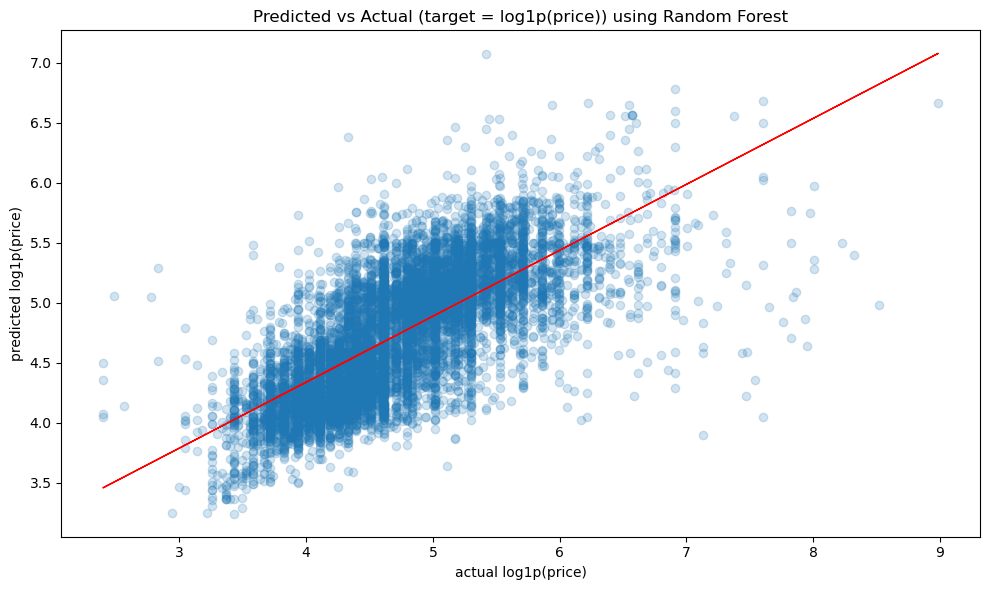

In [149]:
# Predicted vs Actual plot
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.2)
# best-fit line
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + b, color="red", linewidth=1)

plt.title(f"Predicted vs Actual (target = log1p(price)) using {best_name}")
plt.xlabel("actual log1p(price)")
plt.ylabel("predicted log1p(price)")
plt.tight_layout()
plt.show()


In [150]:
# Top 10 absolute errors (on test set)
test_rows = X_test.copy()
test_rows["actual_log_price"] = y_test.values
test_rows["pred_log_price"] = y_pred
test_rows["abs_error"] = np.abs(test_rows["actual_log_price"] - test_rows["pred_log_price"])

top_errors = test_rows.sort_values("abs_error", ascending=False).head(10)
top_errors


,neighbourhood_group,room_type,minimum_nights,number_of_reviews,reviews_per_month_filled,availability_365,host_listing_count,days_since_last_review,actual_log_price,pred_log_price,abs_error
19474,Brooklyn,Private room,5,1,0.16,0,1,184.0,7.601402,4.045145,3.556257
26739,Brooklyn,Entire home/apt,2,8,0.38,0,1,576.0,8.517393,4.984159,3.533234
41770,Manhattan,Private room,100,0,0.00,270,1,NaN,7.955425,4.637326,3.318099
46140,Brooklyn,Private room,30,0,0.00,179,1,NaN,7.467942,4.227149,3.240793
30080,Queens,Shared room,1,1,0.06,173,1,504.0,7.131699,3.897724,3.233975
38220,Manhattan,Private room,180,0,0.00,358,1,NaN,7.539559,4.353625,3.185933
40586,Manhattan,Private room,60,0,0.00,90,1,NaN,7.824446,4.709289,3.115157
22373,Manhattan,Private room,1,0,0.00,89,1,NaN,7.937732,4.864780,3.072951
42736,Manhattan,Entire home/apt,30,0,0.00,180,3,NaN,8.318986,5.400107,2.918879
17811,Queens,Entire home/apt,365,0,0.00,364,1,NaN,7.762596,4.844154,2.918442


## 10. Key Data Insights

In [152]:
insights = [
    "Listing supply is concentrated in a few neighbourhood groups, with Manhattan and Brooklyn typically leading by count.",
    "Room type mix matters: Entire home/apt listings tend to have higher capped prices than private rooms.",
    "Availability and minimum nights show weak-to-moderate relationships with price, but the patterns are noisy.",
    "Professional hosts (5+ listings) can have a different price distribution than non-professional hosts, suggesting operational differences.",
    "Number of reviews is not a simple proxy for price; popular listings can exist at many price points.",
    "The largest prediction errors often occur for unusual listings, rare combinations, or cases impacted by unobserved factors (quality, exact location, amenities).",
    "Neighbourhood_group level summaries provide a useful high-level view but can hide large variation at neighbourhood level.",
    "Outlier handling is critical for marketplace pricing analysis because extreme listings can distort averages and models.",
]

for i, t in enumerate(insights, 1):
    print(f"{i}. {t}")


1. Listing supply is concentrated in a few neighbourhood groups, with Manhattan and Brooklyn typically leading by count.
2. Room type mix matters: Entire home/apt listings tend to have higher capped prices than private rooms.
3. Availability and minimum nights show weak-to-moderate relationships with price, but the patterns are noisy.
4. Professional hosts (5+ listings) can have a different price distribution than non-professional hosts, suggesting operational differences.
5. Number of reviews is not a simple proxy for price; popular listings can exist at many price points.
6. The largest prediction errors often occur for unusual listings, rare combinations, or cases impacted by unobserved factors (quality, exact location, amenities).
7. Neighbourhood_group level summaries provide a useful high-level view but can hide large variation at neighbourhood level.
8. Outlier handling is critical for marketplace pricing analysis because extreme listings can distort averages and models.


## 11. Key Learnings and Observations

- I had to make several cleaning decisions to make the dataset usable for modeling. For example, I converted the last_review column to a datetime format, filled missing text fields like name and host_name with placeholders, and treated missing reviews_per_month as 0 because those listings likely had no reviews.

- Price had a very skewed distribution with a long right tail. To make modeling more stable, I applied a log1p(price) transformation and capped extreme values at the 99th percentile. Without doing this, a few luxury listings would distort both the plots and the models.

- The plots comparing listings across boroughs were some of the clearest. They showed that the supply of Airbnb listings is highly concentrated in Manhattan and Brooklyn, while boroughs like the Bronx and Staten Island have far fewer listings.

- Room type had a strong relationship with price. Entire homes and apartments were consistently more expensive than private rooms, which makes sense because guests are paying for full privacy and space.

- Some variables that I initially expected to matter a lot, like number of reviews, did not show a simple relationship with price. Popular listings existed across many price levels, suggesting that reviews alone do not determine pricing.

- Comparing professional hosts (those with many listings) to non-professional hosts showed that professionals tend to appear more in higher price ranges, although the difference was not extremely strong. This suggests that professionalism may affect pricing strategy but is not the main driver of price.

- The feature engineering steps helped capture some meaningful structure. For example, creating indicators for room type and host professionalism helped summarize patterns in the data that raw columns alone did not clearly show.

- The Random Forest model performed slightly better than the linear regression model, which suggests that the relationship between features and price is not purely linear. Tree-based models can capture more complex interactions.

- Even with these models, prediction errors were still fairly large. Many listings were predicted poorly, especially unusual or high-end properties. This suggests that important factors like exact location, property quality, amenities, and interior condition are missing from the dataset.

---

> **Overall takeaway:** Marketplace pricing data is noisy and influenced by many hidden variables. Good preprocessing and feature engineering help, but without richer data, models can only capture part of the true pricing dynamics.